In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import hdbscan
import umap

In [2]:
# reading in the words.txt
with open('../data/words.txt', 'r') as f:
    words = f.read().splitlines()

# convert to numpy array
words = np.array(words)
words

array(['birds', 'fuel', 'hammer', 'macabre', 'pray', 'unruly', 'blood',
       'identify', 'opposite', 'erect', 'battle', 'public', 'concern',
       'develop', 'placid', 'surround', 'cart', 'burly', 'empty',
       'bite-sized', 'imaginary', 'zippy', 'tour', 'plate', 'terrible',
       'regular', 'volleyball', 'chemical', 'flaky', 'sophisticated',
       'innate', 'wobble', 'pushy', 'superb', 'truck', 'gainful', 'false',
       'reaction', 'jam', 'tank', 'telling', 'rhetorical', 'encourage',
       'peck', 'meddle', 'sudden', 'offbeat', 'paltry', 'grumpy',
       'entertaining', 'paste', 'cheerful', 'sail', 'exist', 'experience',
       'nod', 'pretty', 'delight', 'wrench', 'neck', 'sable',
       'scientific', 'creator', 'chess', 'general', 'discover', 'selfish',
       'foregoing', 'neat', 'stiff', 'waiting', 'children', 'sort',
       'horse', 'kick', 'rock', 'type', 'hissing', 'harass', 'announce',
       'boat', 'rich', 'birth', 'young', 'vest', 'lush', 'hang', 'letter',
       '

In [3]:
len(words)

300

In [4]:
# encode vectors
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(words, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

In [5]:
# normalize the embeddings
embeddings = normalize(embeddings)

In [6]:
# run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=1, metric='euclidean')
cluster_labels = clusterer.fit_predict(embeddings)

In [7]:
from collections import defaultdict

clusters = defaultdict(list)

for i in range(len(words)):
    label = cluster_labels[i]
    # if it's noise (-1) ignore
    if label == -1:
        continue
    clusters[label].append(words[i])

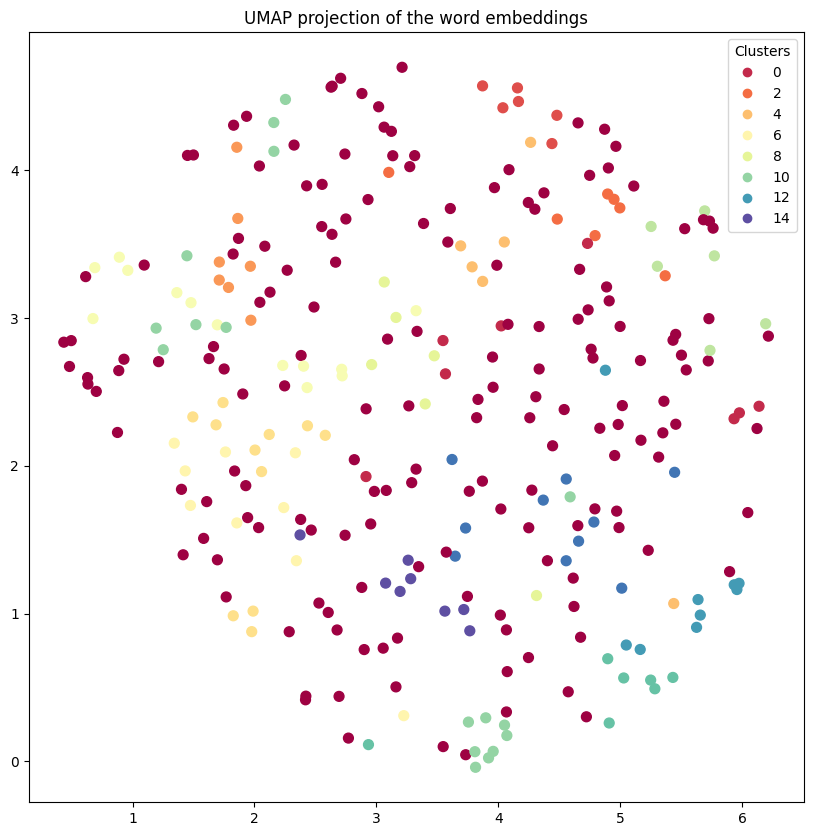

In [8]:
# visualize with umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
embedding_2d = reducer.fit_transform(embeddings)
plt.figure(figsize=(10, 10))
scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=cluster_labels, cmap='Spectral', s=50)
handles, labels = scatter.legend_elements()
plt.legend(handles, labels, title="Clusters")
plt.title('UMAP projection of the word embeddings')
plt.show()

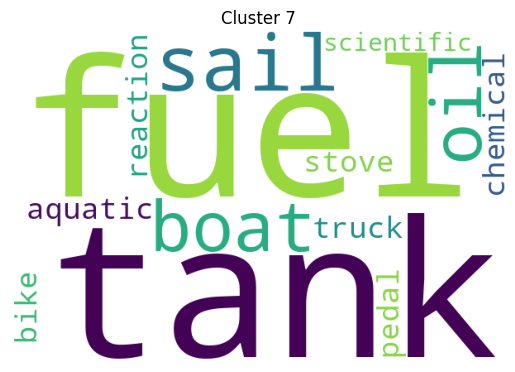

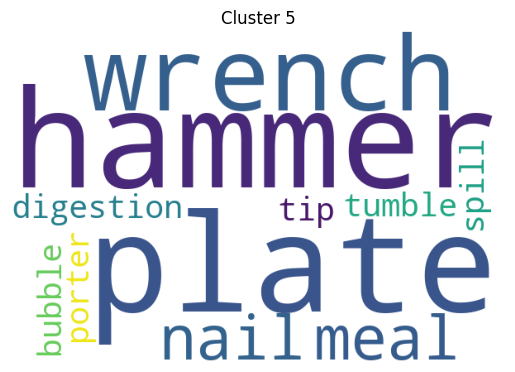

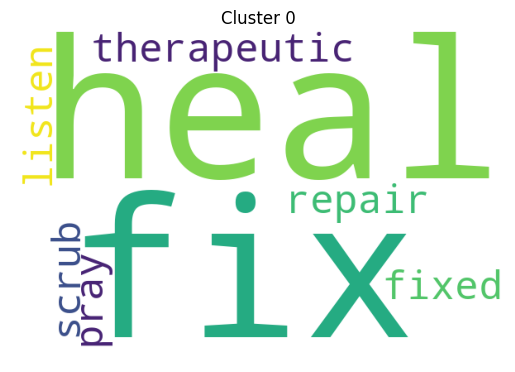

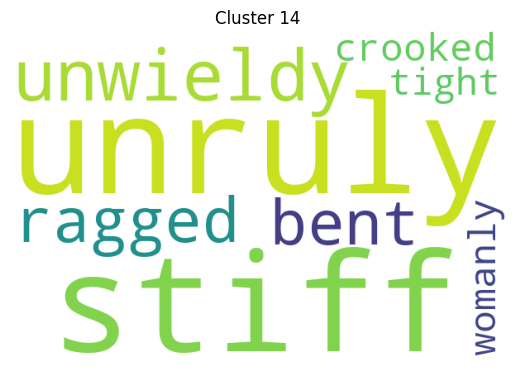

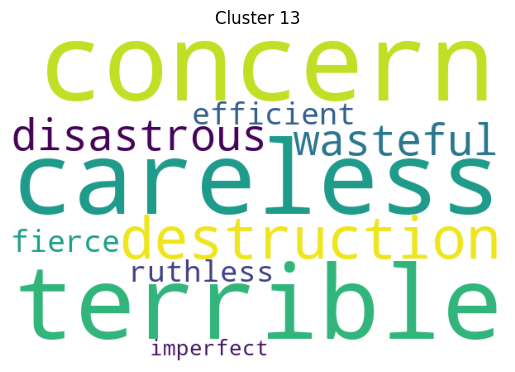

In [9]:
from wordcloud import WordCloud

probs = clusterer.probabilities_

# only first 5 clusters
cluster_ids = list(clusters.keys())[:5]

# for each cluster id, make the word cloud
for cid in cluster_ids:
    freqs = {}

    for i in range(len(words)):
        if cluster_labels[i] != cid:
            continue
            # weighing based on freq
        freqs[words[i]] = probs[i]

    wc = WordCloud(width=600, height=400, background_color="white")
    wc = wc.generate_from_frequencies(freqs)

    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Cluster {cid}")
    plt.show()

In [ ]:
!pip install pandas
import pandas as pd
# Find the maximum length
max_len = max(len(v) for v in clusters.values())

# Pad shorter lists with NaN
for key in clusters:
    if len(clusters[key]) < max_len:
        clusters[key] += [np.nan] * (max_len - len(clusters[key]))

cluster_df = pd.DataFrame(clusters)
cluster_df.to_pickle("../data/cluster.pkl")

In [ ]:
clusters

In [ ]:
# save embeddings to a pickle
embeddings_df = pd.DataFrame(embeddings)
embeddings_df.to_pickle("../data/embeddings.pkl")